 # Data Assessment (Pre-processing)
## Categorical variables: 
- Objects: proto(protocol name), service, state, and attack_cat(attack category)
- Labeled as numerical (ints) but actually categorical binary (0,1): 
- Label (whether there was no attack or an attack)
- is_ftp_login (refer to descriptions)
- is_sm_ips_ports (refer to descriptions) 
## Outliers 
- Outliers were detected in certain variables(dpkts, spkts, bytes,dbytes, sload)
- Source and destination packet counts, source and destination transaction bytes, source bits per second 
- Packets are small chunks of data that get sent over a network when you try to access something 
- High amounts of packets are alarming if the mean is low (could signal an attack)
- Keep them in data and prioritize spotting them 
## Attack types
- Fuzzers: programs that give a combo of inputs to a target and see how it responds
- Analysis: get sensitive information from a device about its weaknesses by scanning files, etc.
- Backdoors: gives unathorized access to a system or network
- DoS(Denial of Service): preventing access to systems, resources, or devices for the user by overwhelming them with traffic 
- Exploits: taking advantage of a vulnerability in the system
- Generic: targets system weaknesses rather than something specific 
- Reconnaissance: scanning or observing systems to find vulnerabilities 
- Shellcode: a piece of code embedded into a vulnerable part of the software to then execute its own code 
- Worms: malicious software that replicates across a system without human interaction
## Summary 
Data had no null values, no duplicate rows, and outliers were spotted but kept, also class imbalance with detection of anamolies (119,341 attacks vs 56,000 normal)

In [ ]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

df = pd.read_csv('../data/UNSW_NB15_training-set.csv')
df.head(15)
#list of all column names
df.columns
#data type/info of variables
df.info()
#finding count of attack and no attack
df['label'].value_counts()
#checking for duplicates of data
df.duplicated().sum()
#all important stats of the data 
df.describe()

# Data Visualization 
- exploits, fuzzers, and DoS are top 3 types of attacks 
- Signals imbalance within type of attack as well:
  - These attacks may over shadow the ones less common (worms and shellcode)
- Box plot for ‘dur’ and ‘label’:
   - Duration in system has a much wider range for attacks as opposed to normal
     - Points to a relationship between dur and attacks, dur may be able to differentiate  between attacks and normal traffic 
- Bar graph for correlation of features with ‘label’
   - Numbers closer to 0 have no correlation or weakest correlation and can be eliminated due to noise 
      - Sloss, sjit, djit
   - Sttl, ct_state_ttl have the highest positive correlation with ‘label’
     - Meaning these have a very high relationship with it so high sttl, ct_state_ttl may signal attack 
  - dload and dmean have the highest negative correlation with ‘label’ 
     - Meaning low dload and dmean may signal an attack 
- Box plot for spkts to label 
  - Source to destination packet count for attacks has a much shorter range than normal traffic but does have much more outliers
    - Lower package count on average (less packets from attacks on average) but higher outliers because DoS attacks tend to flood system with multiple packets
- Box plot for dpkts to label
  - Num of packets the destination sent back for attacks has a shorter range than normal traffic 
    - Attacks also have a min at 0, which points to many attacks not having a destination packet back (like DoS because the system is likely not responding to all of its packets)
      - Corresponds with spkts having many outliers because DoS is sending many packets but dpkts has many mins at 0 because it is not receiving packets or a response back 
      - Lots of outliers which means many packets are indeed responding to the source/attack (typical for exploits)
- Created a count plot for the correlation between is_ftp_login and label 
  - Plot confirmed that there isn’t much usage of ftp login for normal traffic or attacks 
  - Also the correlation between the label and is_ftp_login is very low and close to no correlation at all 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  object 
 3   service            175341 non-null  object 
 4   state              175341 non-null  object 
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  si

<Axes: xlabel='is_ftp_login', ylabel='count'>

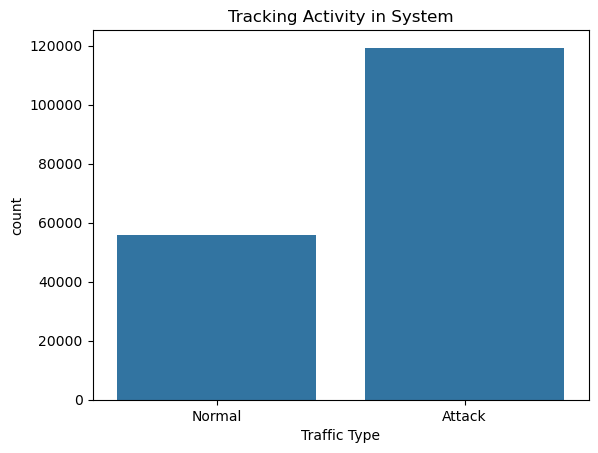

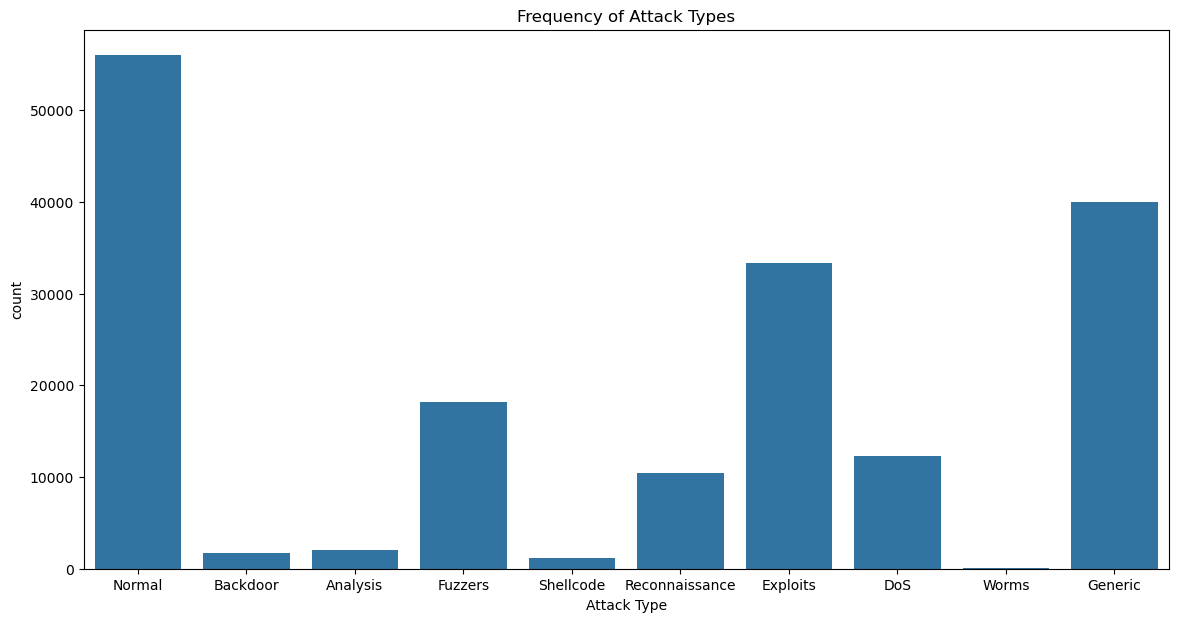

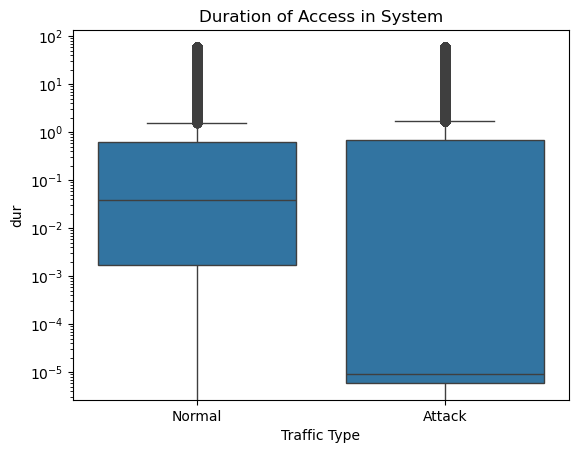

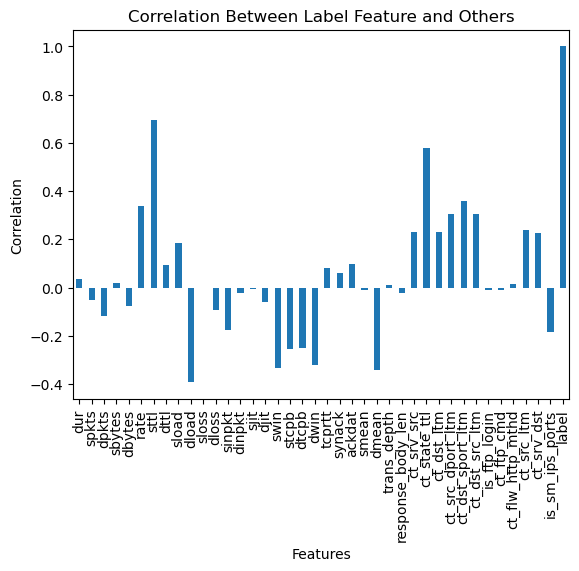

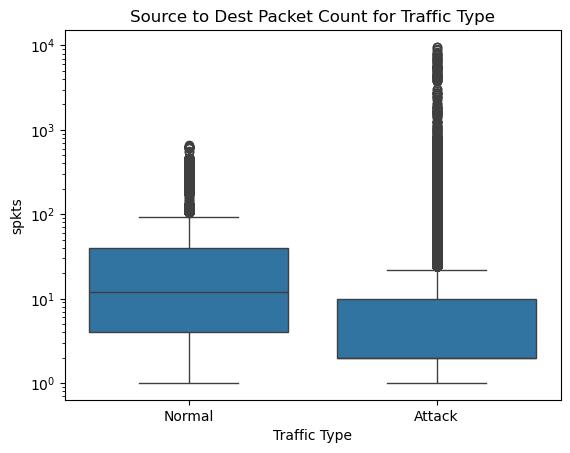

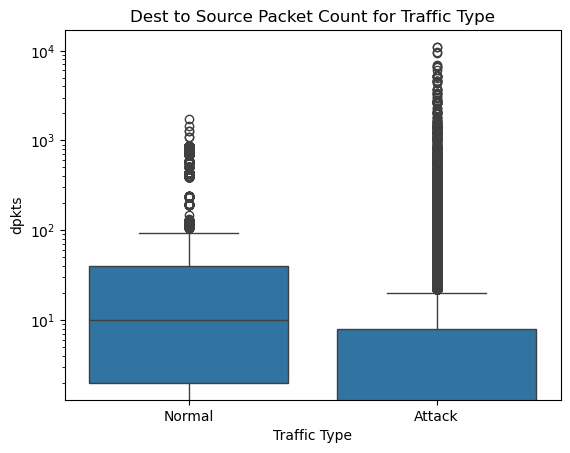

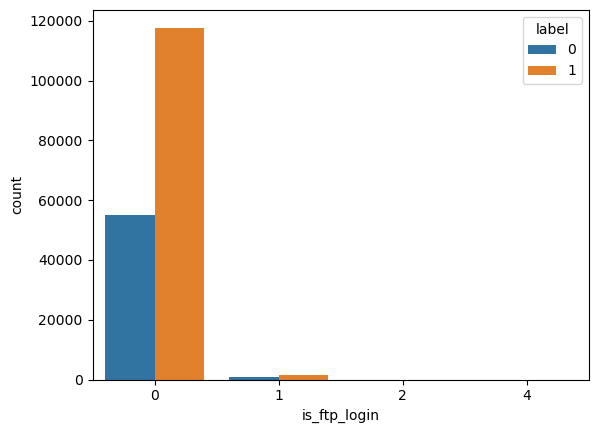

In [ ]:
#visualization of 'label' variable
sns.countplot(data= df, 
              #changing name of 'label' variables to something categorical
              x = df['label'].replace({0: 'Normal', 1:'Attack'}))
plt.xlabel('Traffic Type')
plt.title('Tracking Activity in System')

#visualization of 'attack' variable
plt.figure(figsize=(14,7))
sns.countplot(data=df,
              x = 'attack_cat')
plt.xlabel('Attack Type')
plt.title('Frequency of Attack Types')

#visualization for distribution between dur and label 
plt.figure()
sns.boxplot(data=df, x= df['label'].replace({0: 'Normal', 1:'Attack'}), y='dur')
plt.yscale('log')
plt.title('Duration of Access in System')
plt.xlabel('Traffic Type')

#bar graph for correlation between 'label' feature and others
plt.figure()
corr_label= df.drop(['id', 'proto', 'service', 'state', 'attack_cat'], axis=1).corrwith(df['label'])
corr_label.plot(kind='bar')
plt.title('Correlation Between Label Feature and Others') 
plt.xlabel('Features')
plt.ylabel('Correlation')

#visualization for distribution between spkts and label
plt.figure()
sns.boxplot(data=df, x= df['label'].replace({0: 'Normal', 1:'Attack'}), y='spkts')
#Scaling the plot
plt.yscale('log')
plt.title('Source to Dest Packet Count for Traffic Type')
plt.xlabel('Traffic Type')

#visualization for distribution between dpkts and label
plt.figure()
sns.boxplot(data=df, x= df['label'].replace({0: 'Normal', 1:'Attack'}), y='dpkts')
#Scaling the plot
plt.yscale('log')
plt.title('Dest to Source Packet Count for Traffic Type')
plt.xlabel('Traffic Type')

#bar graph for correlation between 'label' feature and others
plt.figure()
sns.countplot(data=df, x='is_ftp_login', hue = 'label') 

In [53]:
print(corr_label)
df.groupby('label')['dpkts'].describe()
top_protocols = df['proto'].value_counts().head(10).index
print(top_protocols)

dur                  0.036175
spkts               -0.052178
dpkts               -0.118591
sbytes               0.018576
dbytes              -0.076871
rate                 0.337979
sttl                 0.692741
dttl                 0.095049
sload                0.182870
dload               -0.393739
sloss               -0.000640
dloss               -0.094685
sinpkt              -0.176110
dinpkt              -0.022887
sjit                -0.007069
djit                -0.060870
swin                -0.333633
stcpb               -0.255006
dtcpb               -0.250340
dwin                -0.319626
tcprtt               0.081584
synack               0.058299
ackdat               0.097364
smean               -0.010798
dmean               -0.341806
trans_depth          0.010801
response_body_len   -0.021361
ct_srv_src           0.229044
ct_state_ttl         0.577704
ct_dst_ltm           0.229887
ct_src_dport_ltm     0.305579
ct_dst_sport_ltm     0.357213
ct_dst_src_ltm       0.303855
is_ftp_log